
INTERPRETATION:
Electricity usage increases as temperature rises. 
This suggests higher cooling demand (e.g., air conditioning) at higher temperatures.
The relationship appears approximately linear, making regression a suitable model.


INTERPRETATION:
The regression model confirms a strong positive relationship between temperature and electricity usage.
At 42°C, predicted electricity usage is approximately 346.44 kWh.
This estimate lies within the observed range, indicating a reliable prediction.

Columns detected: ['Year', 'Passengers']

INTERPRETATION:
Passenger numbers show a clear upward trend over time.
There is also a repeating seasonal pattern, indicating peaks occur in similar months each year.
This confirms the data is non-stationary and includes both trend and seasonality.


INTERPRETATION:
The linear trend captures the overall growth in passenger numbers.
However, it does not capture seasonal fluctuations.
The difference between the observed data and the trend represents s

/home/snow/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



INTERPRETATION:
The decomposition separates the data into key components:
- Trend: steady long-term increase in passengers.
- Seasonality: consistent yearly pattern in demand.
- Residuals: random noise not explained by the model.
This confirms that a seasonal forecasting model is necessary.


INTERPRETATION:
ARIMA captures the overall upward trend in passenger numbers.
However, it does not account for seasonality, resulting in a smoother forecast.
This limits its effectiveness for data with strong seasonal patterns.



/home/snow/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/snow/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/snow/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_4026/2789024676.py:163: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(
/home/snow/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._


INTERPRETATION:
SARIMA captures both trend and seasonality effectively.
The forecast reflects repeating seasonal patterns seen in historical data.
The confidence interval shows the uncertainty around predictions.
This makes SARIMA the most appropriate model for this dataset.


FINAL INSIGHT SUMMARY:
- Electricity usage increases linearly with temperature.
- Airline passengers data shows both strong trend and seasonality.
- ARIMA models trend but fails to capture seasonality.
- SARIMA provides the most accurate and realistic forecast.
- Understanding data structure is critical for selecting the right model.



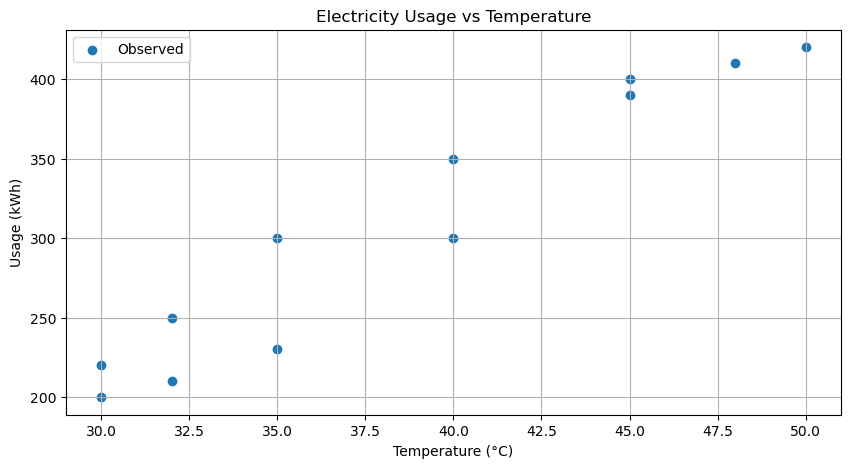

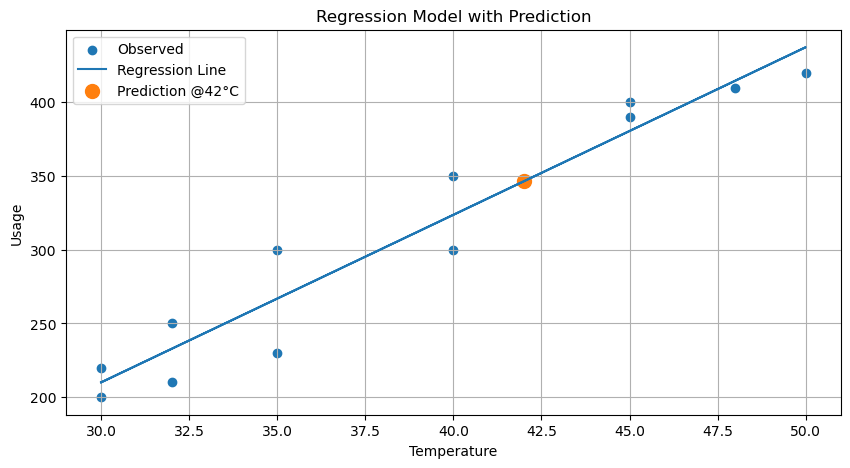

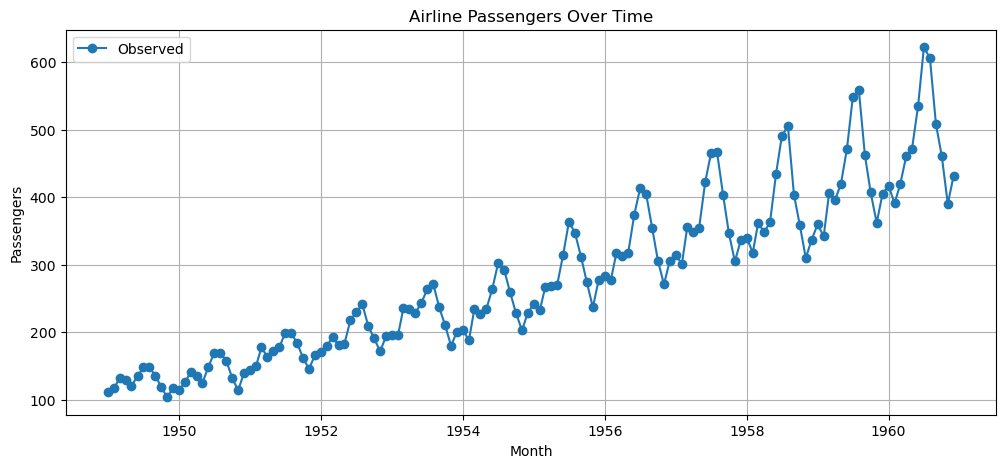

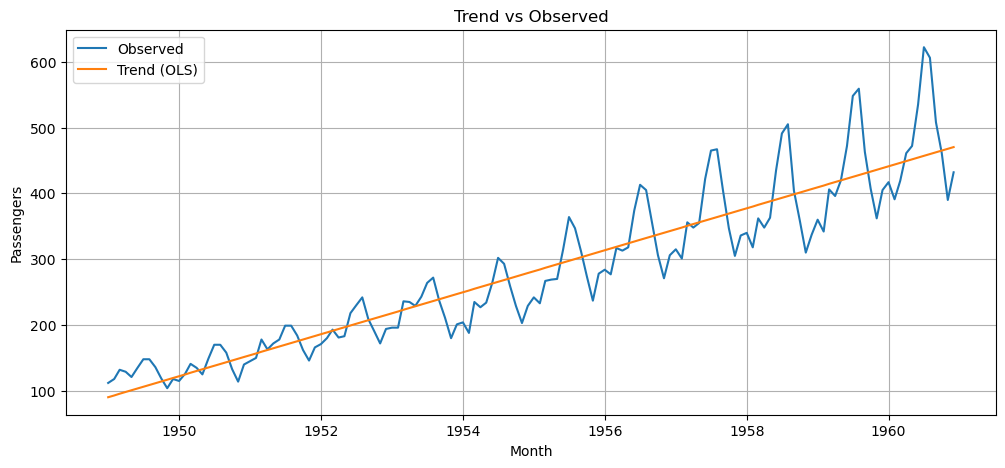

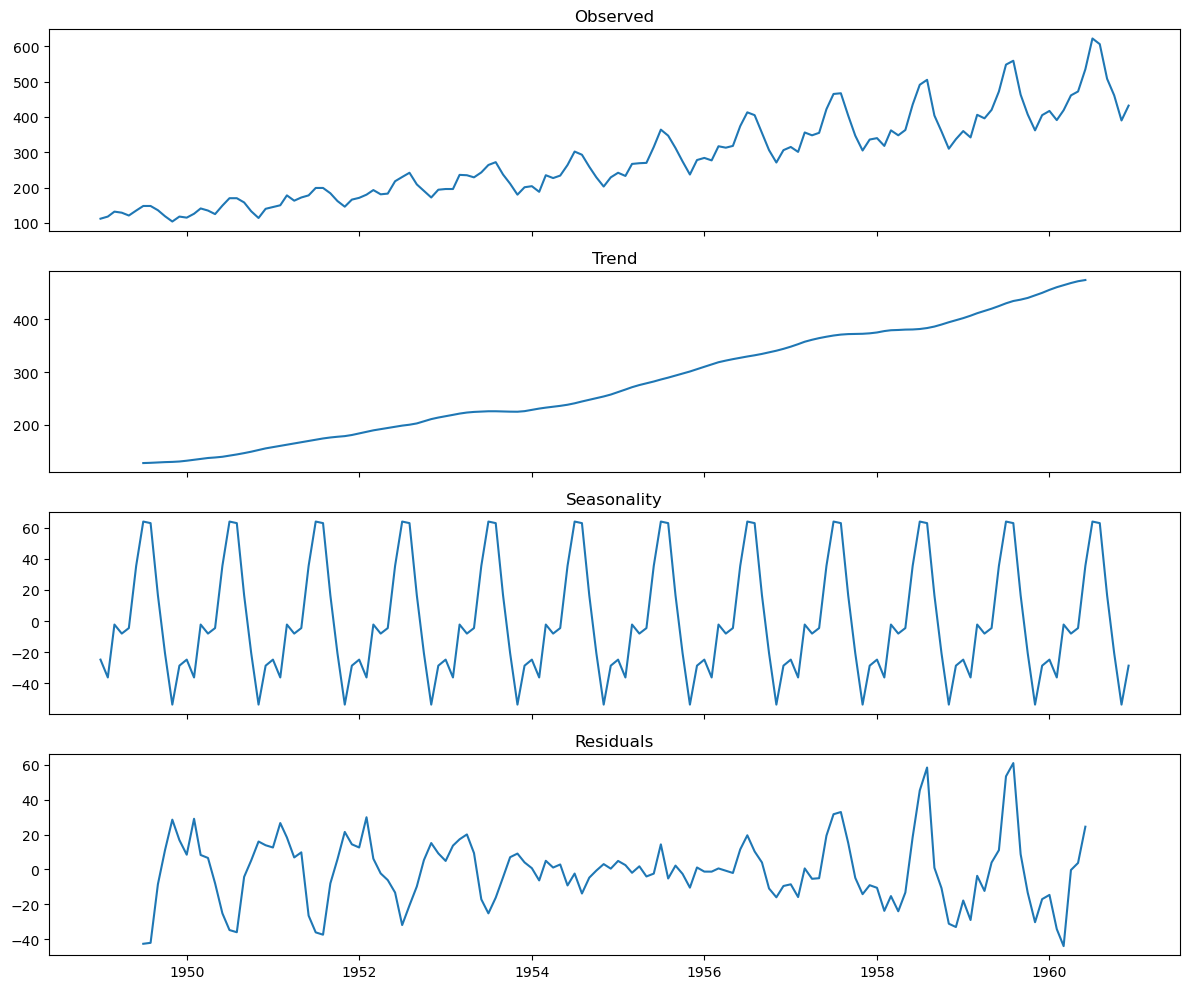

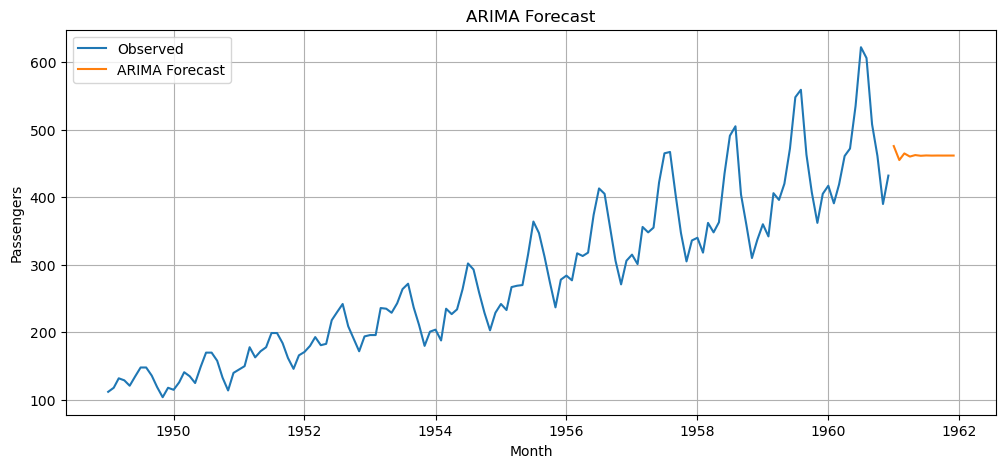

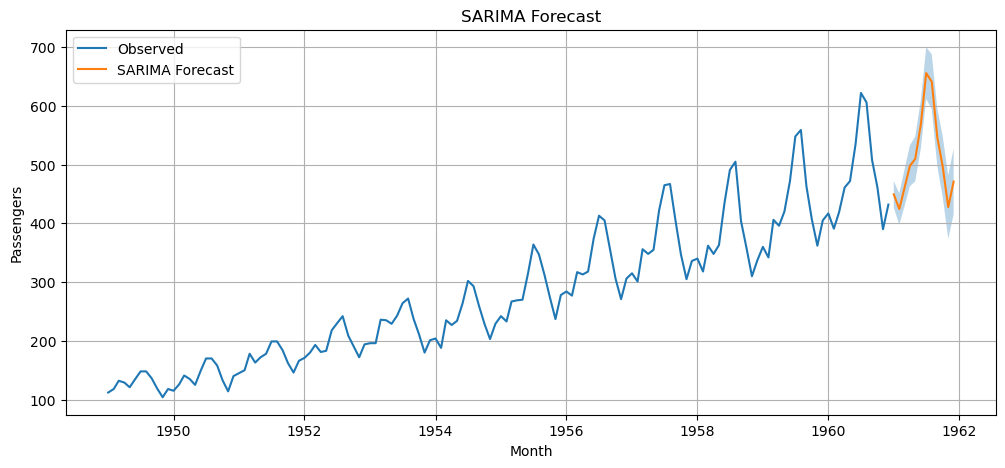

In [ ]:
# =========================================
# TIME SERIES LEARNING LAB ❄️
# Code + Interpretation by Cornelius-Snowhyt
# =========================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from pandas.tseries.offsets import MonthEnd

# =========================================
# PART 1: ELECTRICITY VS TEMPERATURE
# =========================================
df_elec = pd.DataFrame({
    "Temperature": [30, 32, 35, 40, 45, 50, 48, 45, 40, 35, 32, 30],
    "Electricity_Usage": [200, 210, 230, 300, 400, 420, 410, 390, 350, 300, 250, 220]
})

# --- Scatter Plot ---
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(df_elec["Temperature"], df_elec["Electricity_Usage"], label="Observed")
ax.set_title("Electricity Usage vs Temperature")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Usage (kWh)")
ax.legend()
ax.grid(True)
plt.show()

print("""
🔍 INTERPRETATION:
Electricity usage increases as temperature rises, indicating higher demand for cooling.
The relationship appears approximately linear, suggesting linear regression is appropriate.
""")

# --- Regression + Prediction ---
X = df_elec[["Temperature"]]
y = df_elec["Electricity_Usage"]

model = LinearRegression()
model.fit(X, y)

pred_42 = model.predict([[42]])[0]

fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(X, y, label="Observed")
ax.plot(X, model.predict(X), label="Regression Line")
ax.scatter(42, pred_42, label="Prediction @42°C", s=100)
ax.set_title("Regression Model with Prediction")
ax.set_xlabel("Temperature")
ax.set_ylabel("Usage")
ax.legend()
ax.grid(True)
plt.show()

print(f"""
🔍 INTERPRETATION:
The regression confirms a strong positive relationship between temperature and electricity usage.
At 42°C, predicted usage is approximately {pred_42:.2f} kWh.
The prediction falls within the observed range, indicating reasonable reliability.
""")

# =========================================
# PART 2: AIR PASSENGERS TIME SERIES
# =========================================
air = pd.read_csv("air_passengers.csv")

# Clean columns
air.columns = air.columns.str.strip().str.replace("#","")
print("Columns detected:", list(air.columns))

# Fix column name if needed
if "Month" not in air.columns:
    air.rename(columns={air.columns[0]: "Month"}, inplace=True)

# Convert and set index
air["Month"] = pd.to_datetime(air["Month"])
air = air.set_index("Month").sort_index()
air["Passengers"] = pd.to_numeric(air["Passengers"], errors="coerce")

# --- Raw Time Series ---
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(air.index, air["Passengers"], marker='o', label="Observed")
ax.set_title("Airline Passengers Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True)
plt.show()

print("""
🔍 INTERPRETATION:
Passenger numbers show a clear upward trend over time.
A repeating seasonal pattern is visible, indicating peaks occur in similar months each year.
This confirms the data is non-stationary with both trend and seasonality present.
""")

# =========================================
# TREND ANALYSIS (OLS)
# =========================================
air["t"] = np.arange(len(air))
X_air = sm.add_constant(air["t"])
y_air = air["Passengers"]

model_ols = sm.OLS(y_air, X_air).fit()
air["trend"] = model_ols.predict(X_air)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(air.index, air["Passengers"], label="Observed")
ax.plot(air.index, air["trend"], label="Trend (OLS)")
ax.set_title("Trend vs Observed")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True)
plt.show()

print("""
🔍 INTERPRETATION:
The linear trend captures the long-term growth in passenger numbers.
However, it does not account for seasonal fluctuations.
Differences between observed values and the trend represent seasonal and irregular variations.
""")

# =========================================
# DECOMPOSITION
# =========================================
decomp = seasonal_decompose(air["Passengers"], model='additive', period=12)

fig, ax = plt.subplots(4, 1, figsize=(12,10), sharex=True)

ax[0].plot(air.index, decomp.observed)
ax[0].set_title("Observed")

ax[1].plot(air.index, decomp.trend)
ax[1].set_title("Trend")

ax[2].plot(air.index, decomp.seasonal)
ax[2].set_title("Seasonality")

ax[3].plot(air.index, decomp.resid)
ax[3].set_title("Residuals")

plt.tight_layout()
plt.show()

print("""
🔍 INTERPRETATION:
The decomposition reveals:
- Trend: steady long-term increase in passengers.
- Seasonality: consistent yearly travel patterns.
- Residuals: random noise not explained by the model.
This confirms that a seasonal forecasting model is required.
""")

# =========================================
# ARIMA FORECAST
# =========================================
arima = ARIMA(air["Passengers"], order=(1,1,1)).fit()
forecast_arima = arima.forecast(12)

forecast_index = pd.date_range(
    start=air.index[-1] + MonthEnd(1),
    periods=12,
    freq='M'
)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(air.index, air["Passengers"], label="Observed")
ax.plot(forecast_index, forecast_arima, label="ARIMA Forecast")
ax.set_title("ARIMA Forecast")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True)
plt.show()

print("""
🔍 INTERPRETATION:
ARIMA captures the overall trend in the data.
However, it does not model seasonality, resulting in a smoother forecast.
This limits its effectiveness for datasets with strong seasonal patterns.
""")

# =========================================
# SARIMA FORECAST
# =========================================
sarima = SARIMAX(
    air["Passengers"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit(disp=False)

forecast_sarima = sarima.get_forecast(12)
mean_forecast = forecast_sarima.predicted_mean
ci = forecast_sarima.conf_int()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(air.index, air["Passengers"], label="Observed")
ax.plot(forecast_index, mean_forecast, label="SARIMA Forecast")
ax.fill_between(forecast_index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.3)
ax.set_title("SARIMA Forecast")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True)
plt.show()

print("""
🔍 INTERPRETATION:
SARIMA effectively captures both trend and seasonality.
The forecast reflects realistic seasonal patterns seen in historical data.
The confidence interval highlights prediction uncertainty.
This makes SARIMA the most suitable model for this dataset.
""")

# =========================================
# FINAL SUMMARY
# =========================================
print("""
📊 FINAL INSIGHT SUMMARY:
- Electricity usage increases linearly with temperature.
- Airline passenger data exhibits both strong trend and seasonality.
- ARIMA captures trend but fails to model seasonal effects.
- SARIMA provides the most accurate and realistic forecast.
- Understanding data structure is key to selecting the right model.
""")